# **Transfer Learning y Fine-Tuning sobre CIFAR-10**

---
# **1. Dataset**

## **Librerías y configuración global**

In [1]:
import os
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision
from torchvision import datasets, transforms, models

SEED = 123


def fijar_semilla(seed=SEED):
    """Fija las semillas de Python, NumPy y PyTorch para que los experimentos sean reproducibles."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


fijar_semilla()

# Se utiliza la GPU de Apple (MPS) y, si no está disponible, la CPU
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"Versión de PyTorch: {torch.__version__}")
print(f"Versión de torchvision: {torchvision.__version__}")
print(f"Dispositivo: {DEVICE}")
print(f"Semilla: {SEED}")

Versión de PyTorch: 2.14.0
Versión de torchvision: 0.29.0
Dispositivo: mps
Semilla: 123


## **Carga de CIFAR-10**

In [2]:
DATA_DIR = "data"

train = datasets.CIFAR10(root=DATA_DIR, train=True, download=True)
test = datasets.CIFAR10(root=DATA_DIR, train=False, download=True)

CLASES = train.classes

print(f"Imágenes de entrenamiento: {len(train)}")
print(f"Imágenes de test: {len(test)}")
print(f"Número de clases: {len(CLASES)}")
print(f"Clases: {CLASES}")

100%|██████████| 170M/170M [45:50<00:00, 62.0kB/s]   


Imágenes de entrenamiento: 50000
Imágenes de test: 10000
Número de clases: 10
Clases: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


CIFAR-10 es un dataset público de clasificación multiclase compuesto por 60,000 imágenes a color de 32x32 píxeles, distribuidas en 10 categorías: avión, automóvil, pájaro, gato, venado, perro, rana, caballo, barco y camión. Viene dividido en 50,000 imágenes de entrenamiento y 10,000 de test, y cada imagen pertenece a una sola clase, por lo que el problema consiste en asignar la etiqueta correcta a partir de los píxeles.

Se carga mediante `torchvision.datasets.CIFAR10`, donde el parámetro `train` indica si se obtiene el conjunto de entrenamiento o el de test. 

---
# **2. Exploración y preparación de los datos**

**¿Cuántas observaciones y cuántas clases tiene el dataset? ¿Las clases están balanceadas?**

En total, el dataset está compuesto por 60,000 observaciones, de las cuales 50,000 corresponden al conjunto de entrenamiento y 10,000 al conjunto de test. Asimismo, se identifican 10 categorías: airplane, automobile, bird, cat, deer, dog, frog, horse, ship y truck.

En cuanto al balance, todas las categorías están representadas con la misma cantidad de imágenes tanto en entrenamiento como en test, ya que cada clase cuenta con 5,000 imágenes en el primero y 1,000 en el segundo, es decir, un 10 % del total en ambos casos. Esto quiere decir que más adelante, al evaluar los modelos, la accuracy puede utilizarse como una métrica confiable, pues al no existir desbalance el total de aciertos no se ve favorecido por predecir con mayor frecuencia alguna clase dominante. Por ejemplo, un modelo que eligiera siempre la misma categoría obtendría únicamente un 10 % de accuracy, por lo que este valor funciona como la línea base contra la cual se pueden comparar los modelos. No obstante, que los datos estén balanceados no garantiza que el modelo aprenda todas las clases por igual, por lo que la accuracy se complementará con precision, recall y F1-score en su versión macro.

In [3]:
print(f"Observaciones en entrenamiento: {len(train)}")
print(f"Observaciones en test: {len(test)}")
print(f"Observaciones totales: {len(train) + len(test)}")
print(f"Número de clases: {len(CLASES)}")

Observaciones en entrenamiento: 50000
Observaciones en test: 10000
Observaciones totales: 60000
Número de clases: 10


In [4]:
etiquetas_train = pd.Series(train.targets).map(lambda i: CLASES[i])
etiquetas_test = pd.Series(test.targets).map(lambda i: CLASES[i])

# Se calcula la cantidad y el porcentaje de imágenes por clase en cada conjunto
distribucion = pd.DataFrame({
    "Imágenes (train)": etiquetas_train.value_counts(),
    "% (train)": etiquetas_train.value_counts(normalize=True).mul(100).round(2),
    "Imágenes (test)": etiquetas_test.value_counts(),
    "% (test)": etiquetas_test.value_counts(normalize=True).mul(100).round(2),
}).reindex(CLASES)

distribucion

,Imágenes (train),% (train),Imágenes (test),% (test)
airplane,5000,10.0,1000,10.0
automobile,5000,10.0,1000,10.0
bird,5000,10.0,1000,10.0
cat,5000,10.0,1000,10.0
deer,5000,10.0,1000,10.0
dog,5000,10.0,1000,10.0
frog,5000,10.0,1000,10.0
horse,5000,10.0,1000,10.0
ship,5000,10.0,1000,10.0
truck,5000,10.0,1000,10.0


**¿Cuál es la resolución y el número de canales de las imágenes? Calcule la media y desviación estándar por canal del conjunto de entrenamiento y compárelas con las estadísticas de normalización de ImageNet.**

Las imágenes tienen una resolución relativamente baja de 32x32 píxeles y 3 canales, por lo que se trabajará con imágenes a color en formato RGB, donde cada canal toma valores enteros de 0 a 255.

Tras escalar los píxeles al intervalo de 0 a 1, se obtuvo una media de 0.4914, 0.4822 y 0.4465 y una desviación estándar de 0.2470, 0.2435 y 0.2616 para los canales rojo, verde y azul, frente a una media de 0.485, 0.456 y 0.406 y una desviación de 0.229, 0.224 y 0.225 en ImageNet. Los valores son cercanos, aunque CIFAR-10 resulta ligeramente más claro y con mayor contraste, sobre todo en el canal azul. Para la CNN desde cero se utilizarán las estadísticas de CIFAR-10, de tal forma que las entradas queden con media cero y desviación uno, lo cual ayuda a que el entrenamiento sea más estable y converja más rápido. Por otro lado, VGG-16 debe recibir los datos normalizados con las estadísticas de ImageNet, ya que sus filtros aprendieron a partir de esa distribución. Al aplicarlas sobre CIFAR-10, las entradas quedan con una media entre 0.03 y 0.18 y una desviación entre 1.08 y 1.16 según el canal, es decir, muy cerca de lo que el modelo vio durante su preentrenamiento. Esto sugiere que la diferencia de distribución no debería ser un obstáculo para reutilizar sus features, aunque sí existen otras diferencias entre ambos datasets, como la resolución, que se analizarán más adelante.

In [5]:
imagenes_train = train.data  # arreglo de NumPy con forma (imágenes, alto, ancho, canales)

print(f"Forma del conjunto de entrenamiento: {imagenes_train.shape}")
print(f"Resolución: {imagenes_train.shape[1]}x{imagenes_train.shape[2]} píxeles")
print(f"Número de canales: {imagenes_train.shape[3]}")
print(f"Tipo de dato: {imagenes_train.dtype}")
print(f"Rango de valores: [{imagenes_train.min()}, {imagenes_train.max()}]")

Forma del conjunto de entrenamiento: (50000, 32, 32, 3)
Resolución: 32x32 píxeles
Número de canales: 3
Tipo de dato: uint8
Rango de valores: [0, 255]


In [6]:
# Se escalan los píxeles a [0, 1], que es el rango en el que están expresadas las estadísticas de ImageNet
pixeles = imagenes_train.astype(np.float32) / 255.0

MEDIA_CIFAR = pixeles.mean(axis=(0, 1, 2))
STD_CIFAR = pixeles.std(axis=(0, 1, 2))

MEDIA_IMAGENET = np.array([0.485, 0.456, 0.406])
STD_IMAGENET = np.array([0.229, 0.224, 0.225])

estadisticas = pd.DataFrame({
    "Media CIFAR-10": MEDIA_CIFAR,
    "Media ImageNet": MEDIA_IMAGENET,
    "Desv. CIFAR-10": STD_CIFAR,
    "Desv. ImageNet": STD_IMAGENET,
}, index=["Rojo", "Verde", "Azul"]).round(4)

estadisticas

,Media CIFAR-10,Media ImageNet,Desv. CIFAR-10,Desv. ImageNet
Rojo,0.4914,0.485,0.2470,0.229
Verde,0.4822,0.456,0.2435,0.224
Azul,0.4465,0.406,0.2616,0.225


**Visualice al menos 5 ejemplos por clase. ¿Qué pares de clases esperan que sean más difíciles de distinguir y por qué?**

Considero que el par más difícil de distinguir será gato y perro, ya que al trabajar con una resolución de 32x32 ambos se reducen a siluetas de animales con pelo y proporciones similares. Por ejemplo, la quinta imagen de perro es un acercamiento en el que no sabría distinguir si se trata de un perro, de un gato o incluso de cualquier otro animal. En contraste, el resto de categorías cuentan con rasgos más característicos, como las alas y la cola del avión, la forma alargada del camión o las patas largas del caballo. No obstante, creo que también podrían presentarse confusiones entre venado y caballo, pues no todos los venados muestran sus cuernos y ambos son cuadrúpedos cafés sobre fondos de pasto; entre automóvil y camión, cuando se trata de camionetas pequeñas; y entre avión, barco y pájaro, ya que suelen aparecer sobre fondos azules de cielo o agua.

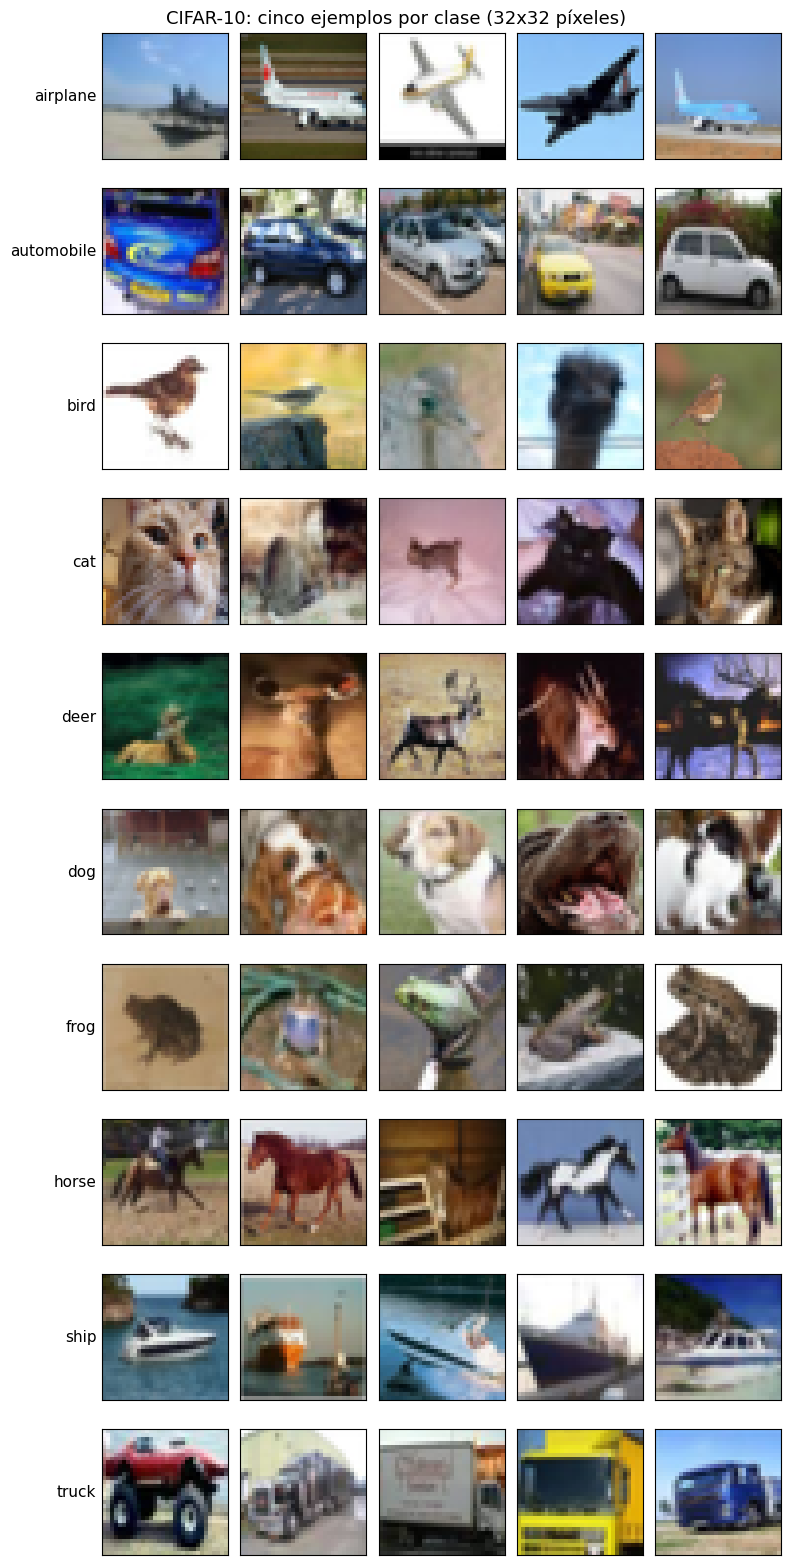

In [7]:
N_EJEMPLOS = 5
rng = np.random.default_rng(SEED)
etiquetas = np.array(train.targets)

fig, axes = plt.subplots(len(CLASES), N_EJEMPLOS, figsize=(N_EJEMPLOS * 1.6, len(CLASES) * 1.6))

# Por cada clase se eligen al azar cinco imágenes del conjunto de entrenamiento
for fila, clase in enumerate(CLASES):
    indices = rng.choice(np.where(etiquetas == fila)[0], size=N_EJEMPLOS, replace=False)
    for col, idx in enumerate(indices):
        ax = axes[fila, col]
        ax.imshow(train.data[idx])
        ax.set_xticks([])
        ax.set_yticks([])
    axes[fila, 0].set_ylabel(clase, rotation=0, ha="right", va="center", fontsize=11)

fig.suptitle("CIFAR-10: cinco ejemplos por clase (32x32 píxeles)", fontsize=13)
plt.tight_layout()
plt.show()

**¿Qué transformaciones de preprocesamiento necesita cada modelo? Defina un pipeline para la CNN desde cero (resolución nativa) y otro para VGG-16 (redimensionamiento y normalización de ImageNet). ¿Qué pasa con el número de píxeles, y por lo tanto con el cómputo, al pasar de 32x32 a 224x224?**

La CNN desde cero solo necesita `ToTensor`, que reordena las dimensiones a (canales, alto, ancho) y escala los valores al intervalo de 0 a 1, seguido de `Normalize` con las estadísticas de CIFAR-10, ya que se diseñará para trabajar directamente con la resolución nativa de 32x32. En el caso de VGG-16, primero se aplica `Resize`, pues sus filtros aprendieron a reconocer patrones a la escala de las imágenes de ImageNet, y para poder aprovechar ese conocimiento previo los objetos deben aparecer a un tamaño similar. Luego se aplican `ToTensor` y `Normalize` con las estadísticas de ImageNet. Cabe mencionar que no se utilizó el recorte central que incluye `weights.transforms()`, ya que las imágenes de CIFAR-10 están encuadradas sobre el objeto y el recorte eliminaría parte de este.

Al pasar de 32x32 a 224x224 el número de píxeles aumenta 49 veces, de 1,024 a 50,176 por canal, y dado que cada convolución recorre todas las posiciones de la imagen, su costo crece en la misma proporción. En VGG-16 esto se traduce en pasar de 0.44 a 15.48 GMACs por imagen, es decir, unas 35 veces más, ya que las capas densas del clasificador mantienen un costo fijo gracias al `AdaptiveAvgPool2d`. Además, redimensionar no agrega información, sino que solo interpola los píxeles existentes. Bajo este escenario, y considerando que se entrenará en una Mac, se utilizará una resolución de 128x128 para ambos modelos basados en VGG-16, lo cual reduce el costo a 5.14 GMACs por imagen, unas tres veces menos que a 224x224.

In [8]:
RESOLUCION_VGG = 128

# CNN desde cero: resolución nativa y normalización con las estadísticas de CIFAR-10
transform_cnn = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEDIA_CIFAR.tolist(), STD_CIFAR.tolist()),
])

# VGG-16: redimensionamiento y normalización con las estadísticas de ImageNet
transform_vgg = transforms.Compose([
    transforms.Resize((RESOLUCION_VGG, RESOLUCION_VGG)),
    transforms.ToTensor(),
    transforms.Normalize(MEDIA_IMAGENET.tolist(), STD_IMAGENET.tolist()),
])

imagen, etiqueta = train[0]
tensor_cnn = transform_cnn(imagen)
tensor_vgg = transform_vgg(imagen)

print(f"Entrada original: imagen PIL de {imagen.size[0]}x{imagen.size[1]}")
print(f"Tensor para la CNN: {tuple(tensor_cnn.shape)}, media {tensor_cnn.mean():.3f}, desv. {tensor_cnn.std():.3f}")
print(f"Tensor para VGG-16: {tuple(tensor_vgg.shape)}, media {tensor_vgg.mean():.3f}, desv. {tensor_vgg.std():.3f}")

Entrada original: imagen PIL de 32x32
Tensor para la CNN: (3, 32, 32), media -0.261, desv. 0.766
Tensor para VGG-16: (3, 128, 128), media -0.193, desv. 0.790


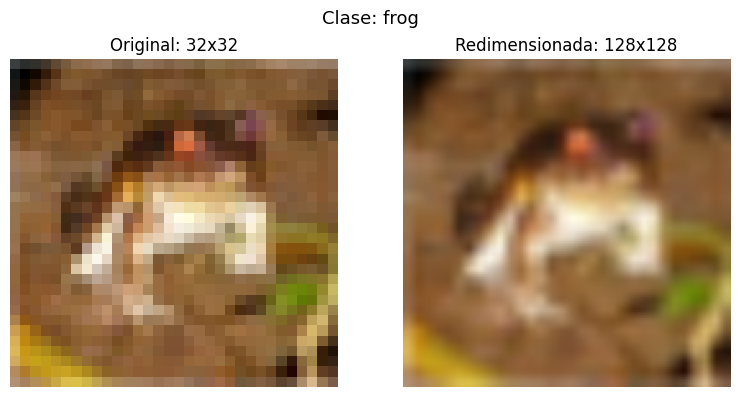

In [9]:
imagen, etiqueta = train[0]
imagen_redimensionada = transforms.Resize((RESOLUCION_VGG, RESOLUCION_VGG))(imagen)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

ax1.imshow(imagen)
ax1.set_title(f"Original: {imagen.size[0]}x{imagen.size[1]}")
ax1.axis("off")

ax2.imshow(imagen_redimensionada)
ax2.set_title(f"Redimensionada: {RESOLUCION_VGG}x{RESOLUCION_VGG}")
ax2.axis("off")

fig.suptitle(f"Clase: {CLASES[etiqueta]}", fontsize=13)
plt.tight_layout()
plt.show()

In [10]:
from torchinfo import summary

# Solo se necesita la arquitectura para contar operaciones, por lo que no se descargan los pesos
vgg_arquitectura = models.vgg16(weights=None)

filas = []
for resolucion in [32, 112, 128, 224]:
    info = summary(vgg_arquitectura, input_size=(1, 3, resolucion, resolucion), verbose=0)
    filas.append({
        "Resolución": f"{resolucion}x{resolucion}",
        "Píxeles por canal": resolucion * resolucion,
        "Veces los píxeles de 32x32": resolucion * resolucion / (32 * 32),
        "MACs de VGG-16 por imagen (G)": round(info.total_mult_adds / 1e9, 2),
    })

costo_resolucion = pd.DataFrame(filas)
costo_resolucion

,Resolución,Píxeles por canal,Veces los píxeles de 32x32,MACs de VGG-16 por imagen (G)
0,32x32,1024,1.00,0.44
1,112x112,12544,12.25,3.96
2,128x128,16384,16.00,5.14
3,224x224,50176,49.00,15.48


**¿Qué técnicas de data augmentation utilizarán y por qué? Justifique por qué la augmentation se aplica solo al conjunto de entrenamiento.**

Se utilizarán tres técnicas: `RandomHorizontalFlip`, que voltea la imagen horizontalmente con una probabilidad del 50 %; `RandomCrop`, que agrega un borde de 4 píxeles y recorta nuevamente una región de 32x32 en una posición aleatoria, simulando pequeños desplazamientos del objeto; y `ColorJitter`, que varía de forma leve el brillo, el contraste, la saturación y el tono. Las dos primeras se eligieron porque no alteran la clase de la imagen, ya que un gato volteado o ligeramente desplazado sigue siendo un gato. Por otro lado, con `ColorJitter` se busca evitar un sesgo por color. Por ejemplo, si 3,000 de las imágenes de gatos fueran de gatos anaranjados, el modelo podría asociar ese color con la clase, por lo que al variarlo se le obliga a enfocarse en formas y patrones más distintivos. En el caso de VGG-16, estas transformaciones se aplican sobre la imagen de 32x32 antes del redimensionamiento.

La augmentation se aplica únicamente al conjunto de entrenamiento porque su propósito es que el modelo vea una versión distinta de cada imagen en cada epoch, lo cual funciona como tener más datos y ayuda a reducir el overfitting. En validación y test, en cambio, se busca medir el desempeño sobre las imágenes tal como son, de tal forma que los resultados sean reproducibles y comparables entre iteraciones, ya que si se aplicaran transformaciones aleatorias la métrica cambiaría en cada evaluación aunque el modelo fuera el mismo.

In [11]:
# Transformaciones aleatorias, aplicadas sobre la imagen de 32x32 antes de cualquier otro paso
augmentation = [
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
]

# Entrenamiento: augmentation seguida del pipeline de cada modelo
transform_cnn_train = transforms.Compose(augmentation + transform_cnn.transforms)
transform_vgg_train = transforms.Compose(augmentation + transform_vgg.transforms)

# Validación y test: únicamente el pipeline de cada modelo, sin transformaciones aleatorias
transform_cnn_eval = transform_cnn
transform_vgg_eval = transform_vgg

print("Pipeline de entrenamiento de la CNN:")
print(transform_cnn_train)
print("\nPipeline de entrenamiento de VGG-16:")
print(transform_vgg_train)

Pipeline de entrenamiento de la CNN:
Compose(
    RandomHorizontalFlip(p=0.5)
    RandomCrop(size=(32, 32), padding=4)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.05, 0.05))
    ToTensor()
    Normalize(mean=[0.49140089750289917, 0.48215895891189575, 0.4465307891368866], std=[0.2470327913761139, 0.243484228849411, 0.261587530374527])
)

Pipeline de entrenamiento de VGG-16:
Compose(
    RandomHorizontalFlip(p=0.5)
    RandomCrop(size=(32, 32), padding=4)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.05, 0.05))
    Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


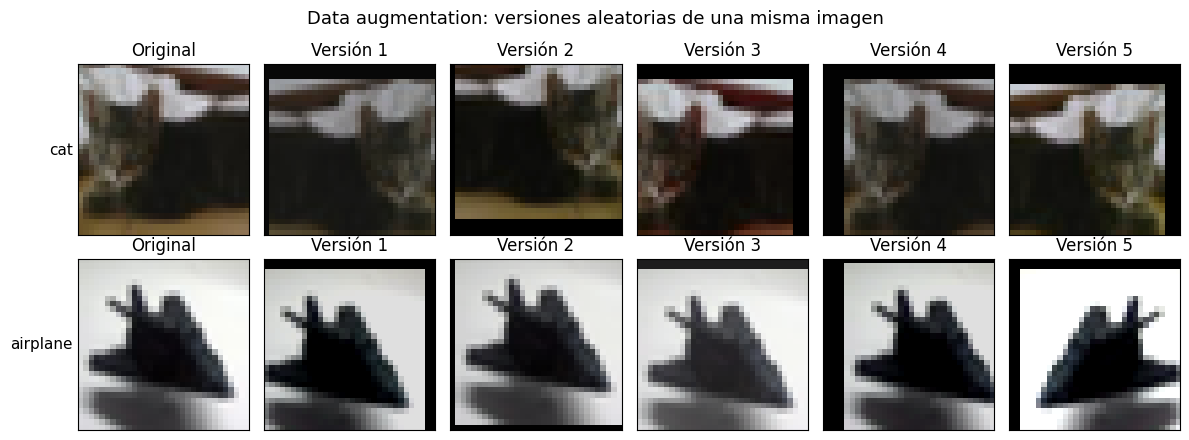

In [12]:
fijar_semilla()
aplicar_augmentation = transforms.Compose(augmentation)
N_VERSIONES = 5

# Se toma la primera imagen de gato y la primera de avión del conjunto de entrenamiento
indices_ejemplo = [np.where(etiquetas == CLASES.index(c))[0][0] for c in ["cat", "airplane"]]

fig, axes = plt.subplots(len(indices_ejemplo), N_VERSIONES + 1, figsize=(12, 4.5))

for fila, idx in enumerate(indices_ejemplo):
    imagen, etiqueta = train[idx]
    axes[fila, 0].imshow(imagen)
    axes[fila, 0].set_title("Original")
    for col in range(1, N_VERSIONES + 1):
        axes[fila, col].imshow(aplicar_augmentation(imagen))
        axes[fila, col].set_title(f"Versión {col}")
    axes[fila, 0].set_ylabel(CLASES[etiqueta], rotation=0, ha="right", va="center", fontsize=11)
    for ax in axes[fila]:
        ax.set_xticks([])
        ax.set_yticks([])

fig.suptitle("Data augmentation: versiones aleatorias de una misma imagen", fontsize=13)
plt.tight_layout()
plt.show()

In [13]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

# División estratificada: 45,000 imágenes para entrenamiento y 5,000 para validación
indices_train, indices_val = train_test_split(
    np.arange(len(train)),
    test_size=5000,
    stratify=etiquetas,
    random_state=SEED,
)


def crear_conjuntos(transform_train, transform_eval):
    """Retorna los conjuntos de entrenamiento, validación y test con los pipelines de un modelo."""
    # Se crean dos instancias del conjunto original para que la validación no reciba augmentation
    base_train = datasets.CIFAR10(root=DATA_DIR, train=True, transform=transform_train)
    base_eval = datasets.CIFAR10(root=DATA_DIR, train=True, transform=transform_eval)
    conjunto_test = datasets.CIFAR10(root=DATA_DIR, train=False, transform=transform_eval)
    return Subset(base_train, indices_train), Subset(base_eval, indices_val), conjunto_test


train_cnn, val_cnn, test_cnn = crear_conjuntos(transform_cnn_train, transform_cnn_eval)
train_vgg, val_vgg, test_vgg = crear_conjuntos(transform_vgg_train, transform_vgg_eval)

print(f"Entrenamiento: {len(train_cnn)} imágenes")
print(f"Validación: {len(val_cnn)} imágenes")
print(f"Test: {len(test_cnn)} imágenes")

# Se verifica que la estratificación mantenga el balance de clases en ambos conjuntos
pd.DataFrame({
    "Imágenes (train)": pd.Series(etiquetas[indices_train]).map(lambda i: CLASES[i]).value_counts(),
    "Imágenes (val)": pd.Series(etiquetas[indices_val]).map(lambda i: CLASES[i]).value_counts(),
}).reindex(CLASES)

Entrenamiento: 45000 imágenes
Validación: 5000 imágenes
Test: 10000 imágenes


,Imágenes (train),Imágenes (val)
airplane,4500,500
automobile,4500,500
bird,4500,500
cat,4500,500
deer,4500,500
dog,4500,500
frog,4500,500
horse,4500,500
ship,4500,500
truck,4500,500
